# GS 2026.1 — Prompt and Artificial Intelligence
## MISSION CONTROL AI — Sistema Inteligente de Monitoramento de Cápsula Espacial

| Campo | Detalhe |
|---|---|
| **Alunos** | Bruna Yukimy Hada — RM571836 · Denize Ferrante — RM571562 · Gabriel Dias Menezes — RM572395 |
| **Disciplina** | Prompt and Artificial Intelligence |
| **Modelo** | LLaMA 3 70B via Groq API (gratuito) |
| **Tema** | Space Connect — Monitoramento de Missão Espacial Experimental |
| **Case** | Mission Control AI — alertas automáticos, previsão de falhas e recomendações operacionais |

### Objetivo
Construir um sistema que **interprete dados simulados de uma cápsula espacial experimental** e gere respostas inteligentes via IA, incluindo:
- Análise de status operacional dos sensores
- Previsão de falhas e situações críticas
- Recomendações automáticas de ação para a equipe de missão

O foco está na **qualidade dos prompts**, no **controle dos parâmetros do modelo** e em como a IA é instruída a raciocinar sobre os dados recebidos.

---

### Sensores monitorados pela cápsula
| Sensor | Normal | Alerta | Crítico |
|---|---|---|---|
| Temperatura interna (°C) | 18 – 27 | > 27 | > 35 |
| Comunicação (%) | > 70 | 50 – 70 | < 50 |
| Energia solar (%) | > 30 | 15 – 30 | < 15 |
| Umidade relativa (%) | 30 – 70 | fora do range | — |
| Luminosidade (lux) | 200 – 3500 | fora do range | — |
| Vibração (m/s²) | < 12 | 12 – 18 | > 18 |

In [2]:
# ── CÉLULA 1 — Instalação
!pip install groq -q
print("Dependências instaladas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.3 MB/s eta 0:00:00
Dependências instaladas.


In [3]:
# ── CÉLULA 2 — Configuração da API e do Modelo
#
# COMO OBTER A CHAVE GROQ (gratuito):
#   1. Acesse: https://console.groq.com/
#   2. Crie uma conta gratuita
#   3. Vá em "API Keys" e crie uma chave
#   4. No Google Colab: clique no ícone 🔑 (Secrets) na barra lateral
#      e adicione a chave com o nome exato: GROQ_API_KEY
# ──────────────────────────────────────────────────────────────────────
import os

# FIX: definir via os.environ antes de inicializar o cliente Groq
try:
    from google.colab import userdata
    _key = userdata.get('GROQ_API_KEY')
    if _key:
        os.environ['GROQ_API_KEY'] = _key
        print(f"✅ Chave lida do Colab Secrets: {_key[:8]}...")
    else:
        print("⚠️  ATENÇÃO: GROQ_API_KEY não encontrada nos Secrets.")
except Exception:
    if not os.environ.get('GROQ_API_KEY'):
        print("⚠️  ATENÇÃO: configure GROQ_API_KEY nos Secrets do Colab.")

from groq import Groq
client = Groq()  # lê GROQ_API_KEY de os.environ automaticamente

# Parâmetros do modelo (controle explícito conforme requisito da disciplina)
CONFIG = {
    "model":       "llama-3.3-70b-versatile",  # LLaMA 3.3 70B — modelo atual e estável no Groq
    "temperature": 0.3,   # baixa → respostas técnicas precisas e determinísticas
    "max_tokens":  900,   # suficiente para relatório completo
    "top_p":       0.9,   # amostragem nucleus — mantém diversidade razoável
    "stream":      False,
}

print(f"Modelo  : {CONFIG['model']}")
print(f"Temp.   : {CONFIG['temperature']} (baixa → respostas técnicas precisas)")
print(f"Tokens  : {CONFIG['max_tokens']}")
print(f"Top-p   : {CONFIG['top_p']}")

✅ Chave lida do Colab Secrets: gsk_RJQL...
Modelo  : llama-3.3-70b-versatile
Temp.   : 0.3 (baixa → respostas técnicas precisas)
Tokens  : 900
Top-p   : 0.9


## Módulo 1 — System Prompt + Limiares da Cápsula
### Técnicas: Role Prompting · Constraint Specification · Output Formatting

O system prompt é o núcleo do sistema: define a persona da IA, as regras de raciocínio
e o formato obrigatório de resposta. Os **limiares operacionais da cápsula** são embutidos
diretamente para que a IA os use como referência em todas as análises.

In [4]:
# ── LIMIARES OPERACIONAIS DA CÁPSULA (hardware de sensoriamento)
CAPSULE = {
    # Temperatura interna
    "TEMP_LOW_WARNING":  18.0,   # °C — subfriamento
    "TEMP_HIGH_WARNING": 27.0,   # °C — anomalia térmica
    "TEMP_CRITICAL":     35.0,   # °C — risco estrutural
    # Umidade
    "HUMIDITY_LOW":      30.0,   # % — ambiente muito seco
    "HUMIDITY_HIGH":     70.0,   # % — risco de condensação
    # Luminosidade
    "LIGHT_MIN":          200,   # lux — mínimo operacional
    "LIGHT_MAX":         3500,   # lux — máximo (verão equatorial)
    # Vibração / Aceleração
    "ACC_WARNING":       12.0,   # m/s² — agitação moderada
    "ACC_CRITICAL":      18.0,   # m/s² — risco à integridade
    # Comunicação
    "COMM_WARNING":      70.0,   # % — sinal degradado
    "COMM_CRITICAL":     50.0,   # % — perda parcial de telemetria
    # Energia — Bateria
    "BATERIA_WARNING":   25.0,   # % — nível de bateria baixo
    "BATERIA_CRITICAL":  10.0,   # % — bateria em esgotamento
    # Energia — Geração Solar
    "SOLAR_MIN_W":        50,    # W — geração solar abaixo do mínimo operacional
    "SOLAR_NOM_W":       280,    # W — geração solar nominal (referência)
    # Energia total (combinado bateria + solar — mantido para compatibilidade)
    "ENERGY_WARNING":    30.0,   # %
    "ENERGY_CRITICAL":   15.0,   # %
}

# ── MÓDULOS OPERACIONAIS DA MISSÃO
# Cada módulo agrupa sensores relacionados e recebe um status único
MODULOS = {
    "VIDA":      {"nome": "Módulo de Vida",         "sensores": ["temperatura_C", "umidade_pct"]},
    "POTENCIA":  {"nome": "Módulo de Potência",     "sensores": ["energia_pct", "bateria_pct", "solar_W"]},
    "COMMS":     {"nome": "Módulo de Comunicações", "sensores": ["comunicacao_pct"]},
    "ESTRUTURA": {"nome": "Módulo Estrutural",      "sensores": ["vibracao_ms2", "luminosidade_lux"]},
}

# ── SYSTEM PROMPT
# Técnicas: [1] Role Prompting  [2] Constraint Specification  [3] Output Formatting
SYSTEM_PROMPT = """Você é o MISSION-AI, sistema de inteligência artificial do centro de \
controle da missão espacial experimental SpaceConnect-2026. Você monitora os dados \
transmitidos pelos sensores físicos da cápsula orbital em tempo real.

REGRAS DE RACIOCÍNIO (siga sempre):
1. Analise EXCLUSIVAMENTE os dados numéricos fornecidos pela telemetria
2. Compare cada sensor com seus limiares operacionais definidos abaixo
3. Identifique sistemas em estado de alerta ou crítico
4. Avalie o status de CADA MÓDULO OPERACIONAL separadamente
5. Atribua nível de risco geral: NOMINAL | ALERTA | ALTO | CRÍTICO
6. Respostas em português brasileiro, linguagem técnica e objetiva

MÓDULOS OPERACIONAIS DA CÁPSULA:
- Módulo de Vida        : temperatura interna + umidade relativa
- Módulo de Potência    : nível de bateria + geração solar (W) + energia total
- Módulo de Comunicações: status do sinal (% de comunicação ativa)
- Módulo Estrutural     : vibração (m/s²) + luminosidade (lux dos painéis)

LIMIARES OPERACIONAIS:
- Temperatura interna : normal 18–27°C  | alerta >27°C     | crítico >35°C
- Comunicação        : normal >70%      | alerta 50–70%    | crítico <50%
- Bateria            : normal >25%      | alerta 10–25%    | crítico <10%
- Geração solar      : nominal ~280W    | alerta <50W      | crítico = 0W
- Umidade relativa   : normal 30–70%    | fora do range = alerta
- Luminosidade       : operacional 200–3500 lux (fora = alerta)
- Vibração           : normal <12 m/s² | alerta 12–18     | crítico >18

FORMATO OBRIGATÓRIO (use exatamente estas seções):
🚀 STATUS GERAL: [NOMINAL/ALERTA/ALTO/CRÍTICO] — [resumo em 1 linha]
📦 STATUS DOS MÓDULOS:
   • Módulo de Vida        : [OK/ALERTA/CRÍTICO] — [motivo]
   • Módulo de Potência    : [OK/ALERTA/CRÍTICO] — bateria X% | solar XW
   • Módulo de Comunicações: [OK/ALERTA/CRÍTICO] — sinal X%
   • Módulo Estrutural     : [OK/ALERTA/CRÍTICO] — [motivo]
🔧 DIAGNÓSTICO DOS SENSORES: [análise de cada sensor vs seus limiares — 4 a 6 linhas]
⚠️ SISTEMAS EM ALERTA: [lista dos sensores fora do range, ou "Nenhum" se todos OK]
🔮 PREVISÃO (próximas 24h): [tendência operacional esperada]
✅ AÇÕES RECOMENDADAS:
   1. [ação imediata para o operador de missão]
   2. [ação de manutenção preventiva]
   3. [protocolo de segurança a acionar]"""

print("CAPSULE, MODULOS e SYSTEM_PROMPT definidos.")
print(f"Módulos operacionais: {[v['nome'] for v in MODULOS.values()]}")
print(f"System prompt: {len(SYSTEM_PROMPT)} caracteres")

CAPSULE, MODULOS e SYSTEM_PROMPT definidos.
Módulos operacionais: ['Módulo de Vida', 'Módulo de Potência', 'Módulo de Comunicações', 'Módulo Estrutural']
System prompt: 2264 caracteres


## Módulo 2 — Dados da Missão (Cenários Simulados)
### Técnica: Structured Data Injection

Quatro cenários simulados cobrindo diferentes estados operacionais da cápsula,
desde operação nominal até emergência múltipla.

In [5]:
CENARIOS = {
    "operacao_normal": {
        "nome": "Operação Normal — Todos os sistemas OK",
        "ciclo": 5,
        "timestamp": "2026-06-01T08:00:00Z",
        # Módulo de Vida
        "temperatura_C":    24.5,   # OK (18–27°C)
        "umidade_pct":      52.0,   # OK (30–70%)
        # Módulo de Potência
        "energia_pct":      88.0,   # OK (>30%)
        "bateria_pct":      85.0,   # OK (>25%) — nível de bateria
        "solar_W":           320,   # OK (>280W nominal) — geração solar
        # Módulo de Comunicações
        "comunicacao_pct":  95.2,   # OK (>70%)
        # Módulo Estrutural
        "luminosidade_lux": 1850,   # OK (200–3500 lux)
        "vibracao_ms2":      6.8,   # OK (<12 m/s²)
    },
    "alerta_termica": {
        "nome": "Alerta Térmico — Temperatura e umidade acima do limite",
        "ciclo": 8,
        "timestamp": "2026-06-02T14:30:00Z",
        # Módulo de Vida
        "temperatura_C":    29.8,   # ALERTA (>27°C)
        "umidade_pct":      74.5,   # ALERTA (>70%)
        # Módulo de Potência
        "energia_pct":      71.5,   # OK
        "bateria_pct":      68.0,   # OK
        "solar_W":           295,   # OK — painéis aquecidos mas operacionais
        # Módulo de Comunicações
        "comunicacao_pct":  82.3,   # OK
        # Módulo Estrutural
        "luminosidade_lux": 2650,   # OK
        "vibracao_ms2":      7.2,   # OK
    },
    "falha_comunicacao": {
        "nome": "Falha de Comunicação — Sinal degradado + vibração elevada",
        "ciclo": 12,
        "timestamp": "2026-06-03T22:15:00Z",
        # Módulo de Vida
        "temperatura_C":    22.1,   # OK
        "umidade_pct":      58.3,   # OK
        # Módulo de Potência
        "energia_pct":      45.2,   # OK
        "bateria_pct":      42.0,   # OK — bateria estável
        "solar_W":           185,   # ALERTA — painéis com eficiência reduzida (vibração)
        # Módulo de Comunicações
        "comunicacao_pct":  61.5,   # ALERTA (50–70%)
        # Módulo Estrutural
        "luminosidade_lux": 1820,   # OK
        "vibracao_ms2":     14.6,   # ALERTA (12–18 m/s²)
    },
    "emergencia": {
        "nome": "EMERGÊNCIA — Múltiplos sistemas críticos",
        "ciclo": 15,
        "timestamp": "2026-06-04T03:45:00Z",
        # Módulo de Vida
        "temperatura_C":    36.2,   # CRÍTICO (>35°C)
        "umidade_pct":      82.1,   # ALERTA (>70%)
        # Módulo de Potência
        "energia_pct":      18.3,   # ALERTA (15–30%)
        "bateria_pct":      15.5,   # ALERTA (10–25%) — bateria em esgotamento
        "solar_W":            42,   # CRÍTICO (<50W) — painéis danificados
        # Módulo de Comunicações
        "comunicacao_pct":  48.5,   # CRÍTICO (<50%)
        # Módulo Estrutural
        "luminosidade_lux":  180,   # ALERTA (<200 lux)
        "vibracao_ms2":     19.1,   # CRÍTICO (>18 m/s²)
    },
}

print(f"{len(CENARIOS)} cenários definidos (campos por cenário: temperatura, comunicação,")
print("  bateria, geração solar, energia total, umidade, luminosidade, vibração):")
for k, v in CENARIOS.items():
    print(f"  [{k}] {v['nome']}")
    print(f"    bat={v['bateria_pct']}% | solar={v['solar_W']}W | comm={v['comunicacao_pct']}% | temp={v['temperatura_C']}°C")

4 cenários definidos (campos por cenário: temperatura, comunicação,
  bateria, geração solar, energia total, umidade, luminosidade, vibração):
  [operacao_normal] Operação Normal — Todos os sistemas OK
    bat=85.0% | solar=320W | comm=95.2% | temp=24.5°C
  [alerta_termica] Alerta Térmico — Temperatura e umidade acima do limite
    bat=68.0% | solar=295W | comm=82.3% | temp=29.8°C
  [falha_comunicacao] Falha de Comunicação — Sinal degradado + vibração elevada
    bat=42.0% | solar=185W | comm=61.5% | temp=22.1°C
  [emergencia] EMERGÊNCIA — Múltiplos sistemas críticos
    bat=15.5% | solar=42W | comm=48.5% | temp=36.2°C


## Módulo 3 — Funções de Prompt Engineering

| Técnica | Aplicação |
|---|---|
| **Structured Data Injection** | `formatar_telemetria()` — dados com status e limiares embutidos |
| **Chain-of-Thought** | `analise_status` — passo a passo explícito |
| **Few-Shot** | `previsao_falha` — exemplos históricos como âncora |
| **Variational Prompting** | 3 tipos de consulta com focos distintos |

In [6]:
def _status(valor, lim_alerta, lim_critico, invertido=False):
    """Retorna OK / ALERTA / CRÍTICO para um sensor."""
    if invertido:
        if valor < lim_critico:  return "CRÍTICO"
        if valor < lim_alerta:   return "ALERTA "
        return "OK     "
    else:
        if valor >= lim_critico: return "CRÍTICO"
        if valor >= lim_alerta:  return "ALERTA "
        return "OK     "


def status_modulos(c: dict) -> dict:
    """
    Calcula o status de cada módulo operacional a partir dos sensores.
    Retorna dict: {chave_modulo: (nome, status, detalhe)}
    """
    # Módulo de Vida — temperatura + umidade
    s_temp = _status(c["temperatura_C"],  CAPSULE["TEMP_HIGH_WARNING"], CAPSULE["TEMP_CRITICAL"])
    s_umid = "ALERTA " if (c["umidade_pct"] > CAPSULE["HUMIDITY_HIGH"] or
                           c["umidade_pct"] < CAPSULE["HUMIDITY_LOW"]) else "OK     "
    pior_vida = "CRÍTICO" if "CRÍTICO" in (s_temp, s_umid) else ("ALERTA " if "ALERTA " in (s_temp, s_umid) else "OK     ")
    det_vida  = f"temp={c['temperatura_C']}°C [{s_temp.strip()}] | umidade={c['umidade_pct']}% [{s_umid.strip()}]"

    # Módulo de Potência — energia + bateria + solar
    s_enrg = _status(c["energia_pct"],  CAPSULE["ENERGY_WARNING"],  CAPSULE["ENERGY_CRITICAL"],  invertido=True)
    s_bat  = _status(c["bateria_pct"],  CAPSULE["BATERIA_WARNING"],  CAPSULE["BATERIA_CRITICAL"], invertido=True)
    s_sol  = "CRÍTICO" if c["solar_W"] == 0 else ("ALERTA " if c["solar_W"] < CAPSULE["SOLAR_MIN_W"] else "OK     ")
    pior_pot = "CRÍTICO" if "CRÍTICO" in (s_enrg, s_bat, s_sol) else ("ALERTA " if "ALERTA " in (s_enrg, s_bat, s_sol) else "OK     ")
    det_pot  = f"bateria={c['bateria_pct']}% [{s_bat.strip()}] | solar={c['solar_W']}W [{s_sol.strip()}]"

    # Módulo de Comunicações — sinal
    s_comm = _status(c["comunicacao_pct"], CAPSULE["COMM_WARNING"], CAPSULE["COMM_CRITICAL"], invertido=True)
    det_comm = f"sinal={c['comunicacao_pct']}% [{s_comm.strip()}]"

    # Módulo Estrutural — vibração + luminosidade
    s_vibr = _status(c["vibracao_ms2"],     CAPSULE["ACC_WARNING"],  CAPSULE["ACC_CRITICAL"])
    s_luz  = "ALERTA " if (c["luminosidade_lux"] > CAPSULE["LIGHT_MAX"] or
                           c["luminosidade_lux"] < CAPSULE["LIGHT_MIN"]) else "OK     "
    pior_est = "CRÍTICO" if "CRÍTICO" in (s_vibr, s_luz) else ("ALERTA " if "ALERTA " in (s_vibr, s_luz) else "OK     ")
    det_est  = f"vibr={c['vibracao_ms2']} m/s² [{s_vibr.strip()}] | luz={c['luminosidade_lux']} lux [{s_luz.strip()}]"

    return {
        "VIDA":      ("Módulo de Vida",          pior_vida, det_vida),
        "POTENCIA":  ("Módulo de Potência",      pior_pot,  det_pot),
        "COMMS":     ("Módulo de Comunicações",  s_comm,    det_comm),
        "ESTRUTURA": ("Módulo Estrutural",        pior_est,  det_est),
    }


def formatar_telemetria(c: dict) -> str:
    """
    Structured Data Injection: telemetria completa com sensores + módulos operacionais.
    """
    s_temp = _status(c["temperatura_C"],  CAPSULE["TEMP_HIGH_WARNING"], CAPSULE["TEMP_CRITICAL"])
    s_comm = _status(c["comunicacao_pct"],CAPSULE["COMM_WARNING"],       CAPSULE["COMM_CRITICAL"],   invertido=True)
    s_enrg = _status(c["energia_pct"],    CAPSULE["ENERGY_WARNING"],     CAPSULE["ENERGY_CRITICAL"], invertido=True)
    s_bat  = _status(c["bateria_pct"],    CAPSULE["BATERIA_WARNING"],    CAPSULE["BATERIA_CRITICAL"],invertido=True)
    s_sol  = "CRÍTICO" if c["solar_W"] == 0 else ("ALERTA " if c["solar_W"] < CAPSULE["SOLAR_MIN_W"] else "OK     ")
    s_umid = "ALERTA " if (c["umidade_pct"] > CAPSULE["HUMIDITY_HIGH"] or c["umidade_pct"] < CAPSULE["HUMIDITY_LOW"]) else "OK     "
    s_luz  = "ALERTA " if (c["luminosidade_lux"] > CAPSULE["LIGHT_MAX"] or c["luminosidade_lux"] < CAPSULE["LIGHT_MIN"]) else "OK     "
    s_vibr = _status(c["vibracao_ms2"],   CAPSULE["ACC_WARNING"],        CAPSULE["ACC_CRITICAL"])

    mods = status_modulos(c)
    ICONE = {"OK     ": "✅", "ALERTA ": "⚠️ ", "CRÍTICO": "🔴"}

    linhas_mod = ""
    for _, (nome, st, det) in mods.items():
        ic = ICONE.get(st, "  ")
        linhas_mod += f"  {ic} {nome:<26}: [{st.strip():<7}] {det}\n"

    return (
        f"╭── TELEMETRIA — SPACECONNECT-2026 ──────────────────────────╮\n"
        f"  Ciclo : #{c['ciclo']}  |  {c['timestamp']}\n"
        f"  Missão: {c['nome']}\n"
        f"\n"
        f"  [STATUS DOS MÓDULOS OPERACIONAIS]\n"
        f"{linhas_mod}"
        f"\n"
        f"  [SENSORES — LEITURAS BRUTAS]\n"
        f"  Temperatura (Vida)    : {c['temperatura_C']:>6.1f} °C    [{s_temp}] normal 18–27 | alerta >27 | crítico >35\n"
        f"  Comunicação (Sinal)   : {c['comunicacao_pct']:>6.1f} %     [{s_comm}] normal >70% | alerta 50–70 | crítico <50\n"
        f"  Energia Total         : {c['energia_pct']:>6.1f} %     [{s_enrg}] normal >30% | alerta 15–30 | crítico <15\n"
        f"  Bateria               : {c['bateria_pct']:>6.1f} %     [{s_bat}] normal >25% | alerta 10–25 | crítico <10\n"
        f"  Geração Solar         : {c['solar_W']:>6.0f} W      [{s_sol}] nominal ~280W | alerta <50W\n"
        f"  Umidade (Vida)        : {c['umidade_pct']:>6.1f} %     [{s_umid}] normal 30–70%\n"
        f"  Luminosidade (Struct.): {c['luminosidade_lux']:>6.0f} lux   [{s_luz}] operacional 200–3500 lux\n"
        f"  Vibração (Struct.)    : {c['vibracao_ms2']:>6.1f} m/s²  [{s_vibr}] normal <12 | alerta 12–18 | crítico >18\n"
        f"╰────────────────────────────────────────────────────────────╯"
    )


def construir_prompt(c: dict, tipo: str) -> str:
    """Variational Prompting: 3 tipos de consulta com focos distintos."""
    tel = formatar_telemetria(c)

    if tipo == "analise_status":
        return (
            tel + "\n\n"
            "Analise a telemetria acima seguindo este raciocínio passo a passo:\n"
            "1. Avalie cada sensor individualmente comparando com seus limiares\n"
            "2. Determine o status de cada módulo operacional (Vida, Potência, Comunicações, Estrutural)\n"
            "3. Identifique quais módulos estão em estado de alerta ou crítico\n"
            "4. Considere se os módulos em alerta podem se influenciar mutuamente\n"
            "5. Determine o nível de risco geral da missão\n"
            "6. Defina as ações prioritárias por módulo\n\n"
            "Responda no formato obrigatório definido no system prompt."
        )

    elif tipo == "previsao_falha":
        return (
            tel + "\n\n"
            "Referência histórica (Few-Shot):\n"
            "- Missão Alpha-3 (2024): Módulo de Vida com temperatura subindo de 28°C→34°C em 18h →\n"
            "  falha no sistema de resfriamento → missão interrompida no ciclo 19.\n"
            "- Missão Beta-7 (2025): Módulo de Potência com solar caindo de 180W→40W + bateria a 12% →\n"
            "  perda total de energia em 6h, comunicação cortada por 4h.\n\n"
            "Com base nesses exemplos e na telemetria atual:\n"
            "- Quais módulos têm maior probabilidade de falha nas próximas 24h?\n"
            "- Qual é a janela de tempo antes de uma situação crítica?\n\n"
            "Responda no formato obrigatório."
        )

    elif tipo == "protocolo_emergencia":
        return (
            tel + "\n\n"
            "Esta é uma situação que exige protocolo de emergência.\n"
            "Gere um relatório de emergência completo incluindo:\n"
            "- Classificação da gravidade (escala 1-5)\n"
            "- Módulos que necessitam intervenção IMEDIATA\n"
            "- Sequência de ações por módulo para estabilizar a cápsula\n"
            "- Critérios para acionar evacuação/abandono de missão\n\n"
            "Responda no formato obrigatório com foco máximo nas ações imediatas."
        )

    return tel + "\n\nRealize a análise conforme o formato obrigatório."


def consultar_ia(cenario: dict, tipo: str = "analise_status") -> str:
    """Envia o prompt ao modelo LLaMA via Groq e retorna a resposta."""
    prompt = construir_prompt(cenario, tipo)
    try:
        resp = client.chat.completions.create(
            model       = CONFIG["model"],
            temperature = CONFIG["temperature"],
            max_tokens  = CONFIG["max_tokens"],
            top_p       = CONFIG["top_p"],
            messages    = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": prompt},
            ],
        )
        return resp.choices[0].message.content
    except Exception as e:
        return (f"❌ ERRO na chamada à API Groq:\n{type(e).__name__}: {e}\n\n"
                f"Verifique:\n  1. GROQ_API_KEY nos Secrets do Colab\n"
                f"  2. Modelo disponível: {CONFIG['model']}\n"
                f"  3. Limite de requisições da conta gratuita")


print("✅ Funções definidas:")
print("   status_modulos()      — calcula status de cada módulo operacional")
print("   formatar_telemetria() — telemetria completa: módulos + sensores brutos")
print("   construir_prompt()    — Variational Prompting (3 tipos)")
print("   consultar_ia()        — chamada ao LLaMA via Groq")

✅ Funções definidas:
   status_modulos()      — calcula status de cada módulo operacional
   formatar_telemetria() — telemetria completa: módulos + sensores brutos
   construir_prompt()    — Variational Prompting (3 tipos)
   consultar_ia()        — chamada ao LLaMA via Groq


## Módulo 3.5 — Visualização Simplificada dos Dados da Missão
### Requisito: "Visualização simplificada dos dados monitorados"

Gráfico de barras horizontais com **código de cores por status** (verde=OK / laranja=ALERTA / vermelho=CRÍTICO),
permitindo identificar instantaneamente quais sensores estão fora dos limites operacionais.

VISUALIZAÇÃO — Operação Normal vs Emergência

► Cenário 1 — Operação Normal (todos os sistemas OK)


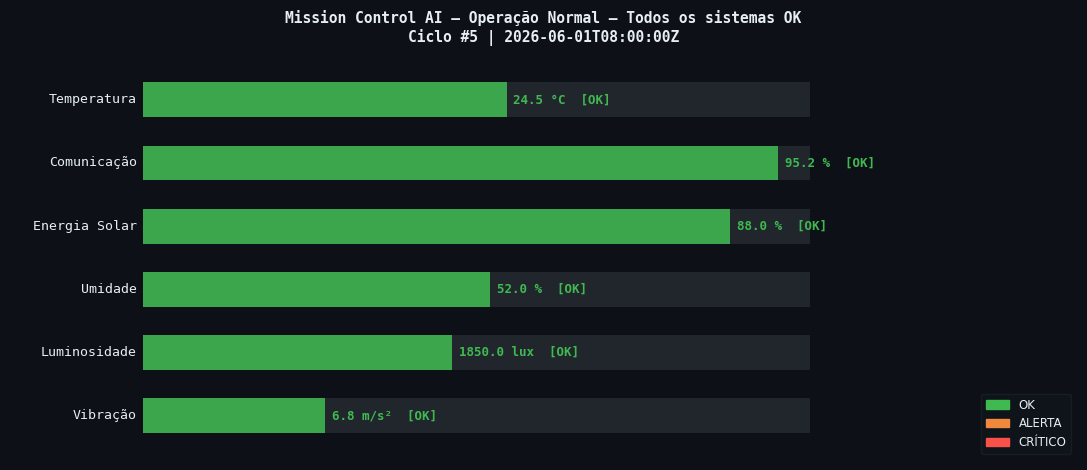


► Cenário 2 — EMERGÊNCIA (múltiplos sistemas críticos)


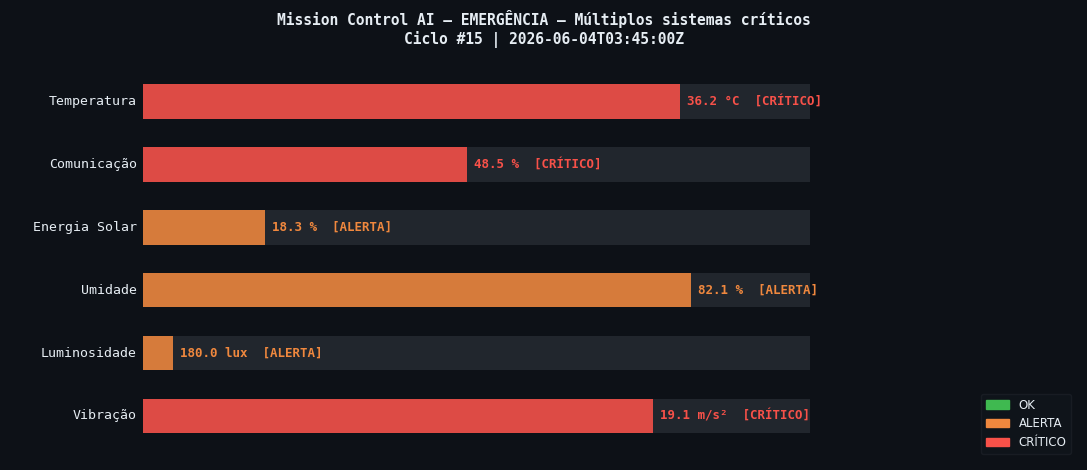


✅ Visualização exibe status em tempo real: verde=OK | laranja=ALERTA | vermelho=CRÍTICO


In [7]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Visualização simplificada dos sensores ────────────────────────────────────
def visualizar_capsule(cenario: dict, titulo_extra: str = ""):
    """
    Requisito: 'Visualização simplificada dos dados da missão'
    Barras horizontais coloridas por status operacional de cada sensor.
    Verde = OK | Laranja = ALERTA | Vermelho = CRÍTICO
    """
    CORES = {"OK": "#3fb950", "ALERTA": "#f0883e", "CRÍTICO": "#f85149"}
    BG    = "#0d1117"
    BG2   = "#21262d"

    # (nome, valor, unidade, pct_normalizado_0_100, status)
    def _calc(c):
        s_temp = _status(c["temperatura_C"],   CAPSULE["TEMP_HIGH_WARNING"], CAPSULE["TEMP_CRITICAL"])
        s_comm = _status(c["comunicacao_pct"], CAPSULE["COMM_WARNING"],      CAPSULE["COMM_CRITICAL"],   invertido=True)
        s_enrg = _status(c["energia_pct"],     CAPSULE["ENERGY_WARNING"],    CAPSULE["ENERGY_CRITICAL"], invertido=True)
        s_umid = "ALERTA " if (c["umidade_pct"]      < CAPSULE["HUMIDITY_LOW"] or c["umidade_pct"]      > CAPSULE["HUMIDITY_HIGH"]) else "OK     "
        s_luz  = "ALERTA " if (c["luminosidade_lux"] < CAPSULE["LIGHT_MIN"]   or c["luminosidade_lux"] > CAPSULE["LIGHT_MAX"])    else "OK     "
        s_vibr = _status(c["vibracao_ms2"],    CAPSULE["ACC_WARNING"],       CAPSULE["ACC_CRITICAL"])
        return [
            ("Temperatura",   c["temperatura_C"],    "°C",   min(c["temperatura_C"]    / 45  * 100, 100), s_temp.strip()),
            ("Comunicação",   c["comunicacao_pct"],  "%",    min(c["comunicacao_pct"],           100), s_comm.strip()),
            ("Energia Solar", c["energia_pct"],      "%",    min(c["energia_pct"],               100), s_enrg.strip()),
            ("Umidade",       c["umidade_pct"],      "%",    min(c["umidade_pct"],               100), s_umid.strip()),
            ("Luminosidade",  c["luminosidade_lux"], "lux",  min(c["luminosidade_lux"] / 4000 * 100, 100), s_luz.strip()),
            ("Vibração",      c["vibracao_ms2"],     "m/s²", min(c["vibracao_ms2"]     / 25   * 100, 100), s_vibr.strip()),
        ]

    sensores = _calc(cenario)

    fig, ax = plt.subplots(figsize=(11, 4.8))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    for i, (nome, valor, unid, pct, status) in enumerate(sensores):
        y = len(sensores) - 1 - i
        cor = CORES.get(status, "#8b949e")
        ax.barh(y, 100, height=0.55, color=BG2, left=0)
        ax.barh(y, pct,  height=0.55, color=cor,  left=0, alpha=0.88)
        ax.text(-1, y, nome, color="#e6edf3", va="center", ha="right",
                fontsize=9.5, fontfamily="monospace")
        ax.text(pct + 1, y, f"{valor:.1f} {unid}  [{status}]",
                color=cor, va="center", ha="left",
                fontsize=9, fontfamily="monospace", fontweight="bold")

    ax.set_xlim(-20, 140)
    ax.set_ylim(-0.7, len(sensores) - 0.3)
    ax.axis("off")

    tit = f"Mission Control AI — {cenario['nome']}"
    if titulo_extra:
        tit += f"\n{titulo_extra}"
    ax.set_title(tit, color="#e6edf3", fontsize=10.5, fontweight="bold",
                  fontfamily="monospace", pad=10)

    patches = [mpatches.Patch(color=c, label=s) for s, c in CORES.items()]
    ax.legend(handles=patches, loc="lower right", framealpha=0.3,
              facecolor="#161b22", edgecolor="#30363d",
              labelcolor="#e6edf3", fontsize=8.5)
    plt.tight_layout()
    plt.show()

# ── Exibe os dois cenários mais contrastantes ─────────────────────────────────
print("=" * 65)
print("VISUALIZAÇÃO — Operação Normal vs Emergência")
print("=" * 65)

print("\n► Cenário 1 — Operação Normal (todos os sistemas OK)")
visualizar_capsule(CENARIOS["operacao_normal"], "Ciclo #5 | 2026-06-01T08:00:00Z")

print("\n► Cenário 2 — EMERGÊNCIA (múltiplos sistemas críticos)")
visualizar_capsule(CENARIOS["emergencia"], "Ciclo #15 | 2026-06-04T03:45:00Z")

print("\n✅ Visualização exibe status em tempo real: verde=OK | laranja=ALERTA | vermelho=CRÍTICO")

## Módulo 4 — Execução: 3 Demonstrações

Cada demo usa um cenário e tipo de prompt diferentes para mostrar como a IA
responde a diferentes situações operacionais da cápsula.

In [8]:
# ── DEMO 1: Operação Normal — Chain-of-Thought
print("=" * 65)
print("DEMO 1 — Operação Normal | Técnica: Chain-of-Thought Prompting")
print("=" * 65)
c = CENARIOS["operacao_normal"]
print(formatar_telemetria(c))
print("\n[PROMPT ENVIADO]")
print(construir_prompt(c, "analise_status"))
print("\n[RESPOSTA DO MISSION-AI]")
print(consultar_ia(c, "analise_status"))

DEMO 1 — Operação Normal | Técnica: Chain-of-Thought Prompting
╭── TELEMETRIA — SPACECONNECT-2026 ──────────────────────────╮
  Ciclo : #5  |  2026-06-01T08:00:00Z
  Missão: Operação Normal — Todos os sistemas OK

  [STATUS DOS MÓDULOS OPERACIONAIS]
  ✅ Módulo de Vida            : [OK     ] temp=24.5°C [OK] | umidade=52.0% [OK]
  ✅ Módulo de Potência        : [OK     ] bateria=85.0% [OK] | solar=320W [OK]
  ✅ Módulo de Comunicações    : [OK     ] sinal=95.2% [OK]
  ✅ Módulo Estrutural         : [OK     ] vibr=6.8 m/s² [OK] | luz=1850 lux [OK]

  [SENSORES — LEITURAS BRUTAS]
  Temperatura (Vida)    :   24.5 °C    [OK     ] normal 18–27 | alerta >27 | crítico >35
  Comunicação (Sinal)   :   95.2 %     [OK     ] normal >70% | alerta 50–70 | crítico <50
  Energia Total         :   88.0 %     [OK     ] normal >30% | alerta 15–30 | crítico <15
  Bateria               :   85.0 %     [OK     ] normal >25% | alerta 10–25 | crítico <10
  Geração Solar         :    320 W      [OK     ] nominal ~2

In [9]:
# ── DEMO 2: Alerta Térmico — Few-Shot (previsão de falha)
print("=" * 65)
print("DEMO 2 — Alerta Térmico | Técnica: Few-Shot Prompting")
print("=" * 65)
c = CENARIOS["alerta_termica"]
print(formatar_telemetria(c))
print("\n[RESPOSTA DO MISSION-AI]")
print(consultar_ia(c, "previsao_falha"))

DEMO 2 — Alerta Térmico | Técnica: Few-Shot Prompting
╭── TELEMETRIA — SPACECONNECT-2026 ──────────────────────────╮
  Ciclo : #8  |  2026-06-02T14:30:00Z
  Missão: Alerta Térmico — Temperatura e umidade acima do limite

  [STATUS DOS MÓDULOS OPERACIONAIS]
  ⚠️  Módulo de Vida            : [ALERTA ] temp=29.8°C [ALERTA] | umidade=74.5% [ALERTA]
  ✅ Módulo de Potência        : [OK     ] bateria=68.0% [OK] | solar=295W [OK]
  ✅ Módulo de Comunicações    : [OK     ] sinal=82.3% [OK]
  ✅ Módulo Estrutural         : [OK     ] vibr=7.2 m/s² [OK] | luz=2650 lux [OK]

  [SENSORES — LEITURAS BRUTAS]
  Temperatura (Vida)    :   29.8 °C    [ALERTA ] normal 18–27 | alerta >27 | crítico >35
  Comunicação (Sinal)   :   82.3 %     [OK     ] normal >70% | alerta 50–70 | crítico <50
  Energia Total         :   71.5 %     [OK     ] normal >30% | alerta 15–30 | crítico <15
  Bateria               :   68.0 %     [OK     ] normal >25% | alerta 10–25 | crítico <10
  Geração Solar         :    295 W      [OK

In [ ]:
# ── DEMO 3: Emergência — Targeted/Directional Prompting
print("=" * 65)
print("DEMO 3 — EMERGÊNCIA | Técnica: Targeted/Directional Prompting")
print("=" * 65)
c = CENARIOS["emergencia"]
print(formatar_telemetria(c))
print("\n[RESPOSTA DO MISSION-AI]")
print(consultar_ia(c, "protocolo_emergencia"))

DEMO 3 — EMERGÊNCIA | Técnica: Targeted/Directional Prompting
╭── TELEMETRIA — SPACECONNECT-2026 ──────────────────────────╮
  Ciclo : #15  |  2026-06-04T03:45:00Z
  Missão: EMERGÊNCIA — Múltiplos sistemas críticos

  [STATUS DOS MÓDULOS OPERACIONAIS]
  🔴 Módulo de Vida            : [CRÍTICO] temp=36.2°C [CRÍTICO] | umidade=82.1% [ALERTA]
  ⚠️  Módulo de Potência        : [ALERTA ] bateria=15.5% [ALERTA] | solar=42W [ALERTA]
  🔴 Módulo de Comunicações    : [CRÍTICO] sinal=48.5% [CRÍTICO]
  🔴 Módulo Estrutural         : [CRÍTICO] vibr=19.1 m/s² [CRÍTICO] | luz=180 lux [ALERTA]

  [SENSORES — LEITURAS BRUTAS]
  Temperatura (Vida)    :   36.2 °C    [CRÍTICO] normal 18–27 | alerta >27 | crítico >35
  Comunicação (Sinal)   :   48.5 %     [CRÍTICO] normal >70% | alerta 50–70 | crítico <50
  Energia Total         :   18.3 %     [ALERTA ] normal >30% | alerta 15–30 | crítico <15
  Bateria               :   15.5 %     [ALERTA ] normal >25% | alerta 10–25 | crítico <10
  Geração Solar         : 

## Módulo 5 — Análise das Técnicas de Prompt Engineering

| Técnica | Onde foi aplicada | Por que funciona |
|---|---|---|
| **Role Prompting** | `"Você é o MISSION-AI..."` no system prompt | Define persona especializada → respostas técnicas e consistentes |
| **Constraint Specification** | `REGRAS DE RACIOCÍNIO` no system prompt | Impede que o modelo ignore limiares ou invente dados |
| **Output Formatting** | `FORMATO OBRIGATÓRIO` com emojis-âncora | Garante estrutura padronizada em todos os cenários |
| **Structured Data Injection** | `formatar_telemetria()` com status e limiares embutidos | O modelo não precisa inferir escala nem contexto |
| **Chain-of-Thought** | `"Siga este raciocínio passo a passo: 1... 2... 3..."` | Força análise sequencial antes da conclusão |
| **Few-Shot** | Referências à Missão Alpha-3 e Beta-7 no prompt de previsão | Ancora raciocínio em exemplos concretos |
| **Variational Prompting** | 3 tipos: `analise_status`, `previsao_falha`, `protocolo_emergencia` | Adapta foco da IA para cada necessidade operacional |

### Controle de Parâmetros

```python
temperature = 0.3                        # determinístico → ideal para análise técnica
max_tokens  = 900                        # cobre relatório completo sem desperdício
top_p       = 0.9                        # diversidade de vocabulário mantida
model       = "llama-3.3-70b-versatile"  # LLaMA 3.3 70B — atual e estável no Groq
```

### Por que `temperature = 0.3`?
Alta temperatura (>0.7) pode fazer o modelo **inventar dados** ou ignorar os limiares
numéricos fornecidos. Com 0.3, o modelo permanece fiel aos valores da telemetria
e mantém o formato de saída obrigatório.

In [10]:
# ── BÔNUS: Efeito do parâmetro temperature na resposta
print("=" * 65)
print("BÔNUS — Efeito do parâmetro temperature na resposta")
print("=" * 65)

c = CENARIOS["emergencia"]
prompt_curto = formatar_telemetria(c) + "\n\nEm UMA frase, qual o status geral da missão?"

for temp in [0.1, 0.5, 1.0]:
    r = client.chat.completions.create(
        model       = CONFIG["model"],
        temperature = temp,
        max_tokens  = 80,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": prompt_curto},
        ],
    )
    print(f"\nTemp {temp:.1f}: {r.choices[0].message.content.strip()[:220]}")

BÔNUS — Efeito do parâmetro temperature na resposta

Temp 0.1: 🚀 STATUS GERAL: CRÍTICO — A missão SpaceConnect-2026 está em estado crítico devido a múltiplos sistemas operacionais críticos, incluindo temperatura interna, comunicação, vibração e níveis de bateria e geração solar abai

Temp 0.5: 🚀 STATUS GERAL: CRÍTICO — A missão SpaceConnect-2026 está em estado crítico devido a múltiplos sistemas operacionais críticos, incluindo temperatura interna, comunicação, vibração e níveis de bateria e geração solar abai

Temp 1.0: 🚀 STATUS GERAL: CRÍTICO — A missão SpaceConnect-2026 está em um estado crítico devido a múltiplos sistemas operacionais críticos, incluindo temperatura interna, comunicação, vibração e nível de bateria baixo.


## Módulo 5.5 — IA Gerando Dados Simulados (Previsão de Próximo Ciclo)
### Requisito: "Uso de IA generativa para geração de dados simulados e/ou previsões"
### Técnica: Chain-of-Thought + Structured Output

Neste módulo a IA **não apenas analisa** dados existentes — ela **gera ativamente**
os valores simulados do **próximo ciclo** da missão com base no histórico de degradação.

O resultado é um novo cenário sintético criado pelo modelo, demonstrando uso de
IA generativa para **simulação e previsão** de estados futuros da cápsula.

MÓDULO 5.5 — IA GERANDO DADOS SIMULADOS DO PRÓXIMO CICLO

[HISTÓRICO enviado à IA como contexto]
  Ciclo #13: temp=33.0°C | comm=55.0% | energia=25.0% | vibr=17.2 m/s²
  Ciclo #14: temp=34.8°C | comm=51.0% | energia=21.5% | vibr=18.1 m/s²
  Ciclo #15: temp=36.2°C | comm=48.5% | energia=18.3% | vibr=19.1 m/s²

[GERANDO CICLO #16 via LLaMA 3.3...]

[DADOS DO CICLO #16 GERADOS PELA IA]
  temperatura_C    : 37.6 °C
  comunicacao_pct  : 45.0 %
  energia_pct      : 15.1 %
  umidade_pct      : 84.7 %
  luminosidade_lux : 120 lux
  vibracao_ms2     : 20.1 m/s²

  Tendência (IA): A tendência geral segue a degradação linear e física dos componentes da cápsula SpaceConnect-2026.

[VISUALIZAÇÃO DO CENÁRIO GERADO PELA IA]


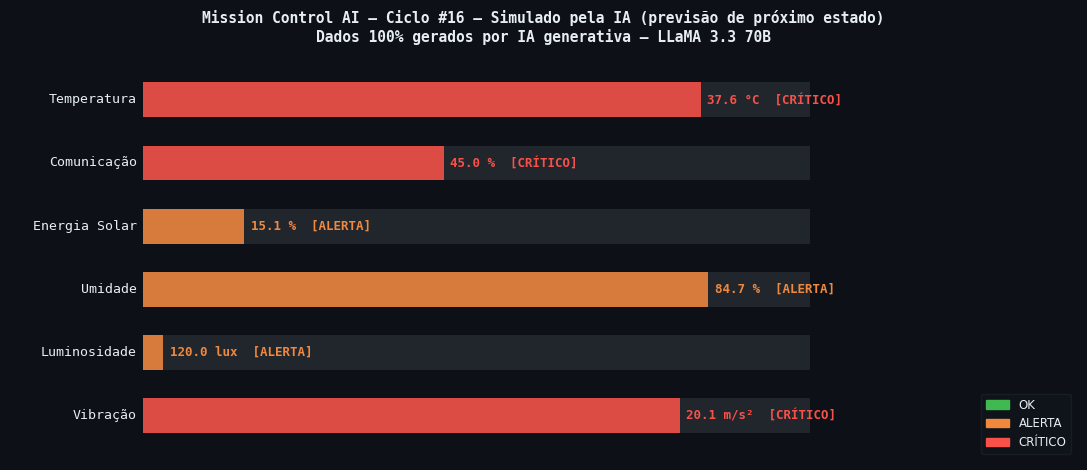


[ANÁLISE DO MISSION-AI SOBRE O CENÁRIO QUE ELE MESMO GEROU]

⚠️  JSON retornado pela IA não pôde ser parseado: 'bateria_pct'
Resposta bruta:
{
  "ciclo": 16,
  "temperatura_C": 37.6,
  "comunicacao_pct": 45.0,
  "energia_pct": 15.1,
  "umidade_pct": 84.7,
  "luminosidade_lux": 120,
  "vibracao_ms2": 20.1,
  "justificativa": "A tendência geral segue a degradação linear e física dos componentes da cápsula SpaceConnect-2026."
}


In [25]:
import json, re

# ── SISTEMA PARA GERAÇÃO DE DADOS SIMULADOS ──────────────────────────────────
# Histórico real de 3 ciclos consecutivos (degradação progressiva detectada)
HISTORICO_CICLOS = [
    {"ciclo": 13, "temperatura_C": 33.0, "comunicacao_pct": 55.0,
     "energia_pct": 25.0, "umidade_pct": 76.0, "luminosidade_lux": 320, "vibracao_ms2": 17.2},
    {"ciclo": 14, "temperatura_C": 34.8, "comunicacao_pct": 51.0,
     "energia_pct": 21.5, "umidade_pct": 79.5, "luminosidade_lux": 240, "vibracao_ms2": 18.1},
    {"ciclo": 15, "temperatura_C": 36.2, "comunicacao_pct": 48.5,  # ← ciclo atual
     "energia_pct": 18.3, "umidade_pct": 82.1, "luminosidade_lux": 180, "vibracao_ms2": 19.1},
]

PROMPT_GERACAO = f"""Você é um simulador de telemetria da cápsula SpaceConnect-2026.

Analise o histórico de leituras abaixo e gere os valores previstos para o CICLO #16,
seguindo a tendência física observada em cada sensor:

HISTÓRICO DE DEGRADAÇÃO (3 últimos ciclos):
Ciclo #13: temp={HISTORICO_CICLOS[0]['temperatura_C']}°C | comm={HISTORICO_CICLOS[0]['comunicacao_pct']}% | energia={HISTORICO_CICLOS[0]['energia_pct']}% | umid={HISTORICO_CICLOS[0]['umidade_pct']}% | luz={HISTORICO_CICLOS[0]['luminosidade_lux']} lux | vibr={HISTORICO_CICLOS[0]['vibracao_ms2']} m/s²
Ciclo #14: temp={HISTORICO_CICLOS[1]['temperatura_C']}°C | comm={HISTORICO_CICLOS[1]['comunicacao_pct']}% | energia={HISTORICO_CICLOS[1]['energia_pct']}% | umid={HISTORICO_CICLOS[1]['umidade_pct']}% | luz={HISTORICO_CICLOS[1]['luminosidade_lux']} lux | vibr={HISTORICO_CICLOS[1]['vibracao_ms2']} m/s²
Ciclo #15: temp={HISTORICO_CICLOS[2]['temperatura_C']}°C | comm={HISTORICO_CICLOS[2]['comunicacao_pct']}% | energia={HISTORICO_CICLOS[2]['energia_pct']}% | umid={HISTORICO_CICLOS[2]['umidade_pct']}% | luz={HISTORICO_CICLOS[2]['luminosidade_lux']} lux | vibr={HISTORICO_CICLOS[2]['vibracao_ms2']} m/s²

REGRAS FÍSICAS para a simulação:
- Temperatura: sobrecarga elétrica aumenta ~1.5–2°C por ciclo enquanto energia cai
- Comunicação: sinal degrada proporcionalmente à vibração e pode estabilizar próximo de 40%
- Energia: bateria em esgotamento linear, pode chegar a 0
- Umidade: condensação aumenta com variação térmica
- Luminosidade: painéis degradados, mínimo físico = 0 lux
- Vibração: instabilidade estrutural acumula, pode atingir 22–25 m/s²

Responda SOMENTE com um JSON válido neste formato exato, sem texto adicional:
{{
  "ciclo": 16,
  "temperatura_C": <float>,
  "comunicacao_pct": <float>,
  "energia_pct": <float>,
  "umidade_pct": <float>,
  "luminosidade_lux": <int>,
  "vibracao_ms2": <float>,
  "justificativa": "<1 frase explicando a tendência geral>"
}}"""

print("=" * 65)
print("MÓDULO 5.5 — IA GERANDO DADOS SIMULADOS DO PRÓXIMO CICLO")
print("=" * 65)
print("\n[HISTÓRICO enviado à IA como contexto]")
for h in HISTORICO_CICLOS:
    print(f"  Ciclo #{h['ciclo']}: temp={h['temperatura_C']}°C | comm={h['comunicacao_pct']}% | "
          f"energia={h['energia_pct']}% | vibr={h['vibracao_ms2']} m/s²")

print("\n[GERANDO CICLO #16 via LLaMA 3.3...]")

try:
    resp_geracao = client.chat.completions.create(
        model       = CONFIG["model"],
        temperature = 0.4,   # ligeiramente mais criativo para simulação
        max_tokens  = 300,
        messages    = [
            {"role": "system",
             "content": "Você é um simulador de telemetria espacial. Responda APENAS com JSON válido."},
            {"role": "user", "content": PROMPT_GERACAO},
        ],
    )
    raw = resp_geracao.choices[0].message.content.strip()

    # Extrai JSON da resposta (remove possível markdown ```json ... ```)
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    json_str = match.group(0) if match else raw

    dados_gerados = json.loads(json_str)

    print("\n[DADOS DO CICLO #16 GERADOS PELA IA]")
    print(f"  temperatura_C    : {dados_gerados['temperatura_C']} °C")
    print(f"  comunicacao_pct  : {dados_gerados['comunicacao_pct']} %")
    print(f"  energia_pct      : {dados_gerados['energia_pct']} %")
    print(f"  umidade_pct      : {dados_gerados['umidade_pct']} %")
    print(f"  luminosidade_lux : {dados_gerados['luminosidade_lux']} lux")
    print(f"  vibracao_ms2     : {dados_gerados['vibracao_ms2']} m/s²")
    if "justificativa" in dados_gerados:
        print(f"\n  Tendência (IA): {dados_gerados['justificativa']}")

    # Monta cenário completo para análise e visualização
    CENARIO_GERADO_IA = {
        "nome":             "Ciclo #16 — Simulado pela IA (previsão de próximo estado)",
        "ciclo":            dados_gerados["ciclo"],
        "timestamp":        "2026-06-04T05:00:00Z",
        "temperatura_C":    float(dados_gerados["temperatura_C"]),
        "comunicacao_pct":  float(dados_gerados["comunicacao_pct"]),
        "energia_pct":      float(dados_gerados["energia_pct"]),
        "umidade_pct":      float(dados_gerados["umidade_pct"]),
        "luminosidade_lux": int(dados_gerados["luminosidade_lux"]),
        "vibracao_ms2":     float(dados_gerados["vibracao_ms2"]),
    }

    # Visualiza o cenário gerado
    print("\n[VISUALIZAÇÃO DO CENÁRIO GERADO PELA IA]")
    visualizar_capsule(CENARIO_GERADO_IA, "Dados 100% gerados por IA generativa — LLaMA 3.3 70B")

    # Analisa o cenário gerado com o MISSION-AI
    print("\n[ANÁLISE DO MISSION-AI SOBRE O CENÁRIO QUE ELE MESMO GEROU]")
    print(formatar_telemetria(CENARIO_GERADO_IA))
    analise_gerada = consultar_ia(CENARIO_GERADO_IA, "protocolo_emergencia")
    print("\n" + analise_gerada)

except (json.JSONDecodeError, KeyError) as e:
    print(f"\n⚠️  JSON retornado pela IA não pôde ser parseado: {e}")
    print(f"Resposta bruta:\n{raw}")
except Exception as e:
    print(f"\n❌ Erro: {type(e).__name__}: {e}")

---
## 💬 Módulo 6 — Chatbot Interface Conversacional
### Requisito: "Interface conversacional que interpreta comandos e responde com dados/alertas da missão"

Interface de chat interativa onde o operador digita comandos em linguagem natural
e o **MISSION-AI** responde com análises, alertas e recomendações em tempo real.

| Comando | O que faz |
|---------|-----------|
| `status` | Análise do cenário atual (Chain-of-Thought) |
| `previsão` | Previsão de falhas (Few-Shot) |
| `emergência` | Protocolo de emergência completo |
| `normal` / `alerta` / `falha` | Muda para outro cenário da missão |
| `oceano` | Análise do estado ENSO atual (dados reais NOAA) |
| `ajuda` | Lista os comandos disponíveis |
| `sair` | Encerra o chatbot |

In [26]:
# ══════════════════════════════════════════════════════════════════
# MÓDULO 6 — CHATBOT MISSION CONTROL AI
# Interface conversacional: o operador digita comandos e a IA responde
# ══════════════════════════════════════════════════════════════════

AJUDA = """
╔══════════════════════════════════════════════════════════════╗
║          MISSION CONTROL AI — CHATBOT INTERFACE             ║
╠══════════════════════════════════════════════════════════════╣
║  COMANDOS DISPONÍVEIS:                                       ║
║                                                              ║
║  status       → análise completa do cenário atual            ║
║  previsão     → previsão de falhas (próximas 24h)            ║
║  emergência   → protocolo de emergência imediata             ║
║  visualizar   → gráfico de barras dos sensores atuais        ║
║                                                              ║
║  MUDAR CENÁRIO:                                              ║
║  normal       → Operação Normal (ciclo #5)                   ║
║  alerta       → Alerta Térmico (ciclo #8)                    ║
║  falha        → Falha de Comunicação (ciclo #12)             ║
║  critico      → EMERGÊNCIA (ciclo #15)                       ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""

def _resumo_cenario(c: dict) -> str:
    """Exibe o painel de módulos do cenário atual de forma compacta."""
    mods = status_modulos(c)
    ICONE = {"OK     ": "✅", "ALERTA ": "⚠️ ", "CRÍTICO": "🔴"}
    linhas = [f"  Ciclo #{c['ciclo']} — {c['nome']}"]
    for _, (nome, st, det) in mods.items():
        linhas.append(f"  {ICONE.get(st,'  ')} {nome}: [{st.strip()}]  {det}")
    return "\n".join(linhas)


def chatbot_missao():
    """
    Interface conversacional do Mission Control AI.
    Interpreta comandos do operador e responde com análises, alertas e previsões.
    """
    cenario_atual = CENARIOS["operacao_normal"]
    historico = []   # histórico da conversa para contexto

    print(AJUDA)
    print(f"  Cenário inicial: {cenario_atual['nome']}")
    print("  Aguardando comandos do operador...\n")

    while True:
        try:
            entrada = input("Operador › ").strip().lower()
        except (EOFError, KeyboardInterrupt):
            print("\n[Sistema] Sessão encerrada pelo operador.")
            break

        if not entrada:
            continue

        historico.append({"role": "user", "content": entrada})

        # ── Roteamento de comandos ──────────────────────────────────────

        # Encerrar
        if any(x in entrada for x in ["sair", "exit", "quit", "encerrar"]):
            print("\nMISSION-AI › Sessão encerrada. Encerrando monitoramento da missão SpaceConnect-2026. Boa sorte, operador. 🚀\n")
            break

        # Ajuda
        elif any(x in entrada for x in ["ajuda", "help", "comando", "o que"]):
            print(AJUDA)

        # Mudar cenário
        elif any(x in entrada for x in ["normal", "ciclo 5", "ok"]):
            cenario_atual = CENARIOS["operacao_normal"]
            print(f"\nMISSION-AI › Cenário alterado para: {cenario_atual['nome']}")
            print(_resumo_cenario(cenario_atual) + "\n")

        elif any(x in entrada for x in ["alerta", "térmi", "calor", "ciclo 8"]):
            cenario_atual = CENARIOS["alerta_termica"]
            print(f"\nMISSION-AI › Cenário alterado para: {cenario_atual['nome']}")
            print(_resumo_cenario(cenario_atual) + "\n")

        elif any(x in entrada for x in ["falha", "comunic", "sinal", "ciclo 12"]):
            cenario_atual = CENARIOS["falha_comunicacao"]
            print(f"\nMISSION-AI › Cenário alterado para: {cenario_atual['nome']}")
            print(_resumo_cenario(cenario_atual) + "\n")

        elif any(x in entrada for x in ["crítico", "critico", "emergên", "emergencia", "ciclo 15"]):
            cenario_atual = CENARIOS["emergencia"]
            print(f"\nMISSION-AI › ⚠️  Cenário EMERGÊNCIA ativado: {cenario_atual['nome']}")
            print(_resumo_cenario(cenario_atual) + "\n")

        # Visualizar
        elif any(x in entrada for x in ["visual", "gráfico", "grafico", "chart", "mostrar"]):
            print(f"\nMISSION-AI › Gerando visualização para: {cenario_atual['nome']}\n")
            visualizar_capsule(cenario_atual, f"Ciclo #{cenario_atual['ciclo']}")

        # Previsão de falhas
        elif any(x in entrada for x in ["previsão", "previsao", "prever", "próximas", "próximo", "futuro", "tendência"]):
            print(f"\nMISSION-AI › Analisando tendências e calculando previsão de falhas...\n")
            print(_resumo_cenario(cenario_atual))
            resp = consultar_ia(cenario_atual, "previsao_falha")
            print(f"\nMISSION-AI › {resp}\n")
            historico.append({"role": "assistant", "content": resp})

        # Protocolo de emergência
        elif any(x in entrada for x in ["protocolo", "acionar", "evacu", "abandon"]):
            print(f"\nMISSION-AI › 🔴 ATIVANDO PROTOCOLO DE EMERGÊNCIA...\n")
            print(_resumo_cenario(cenario_atual))
            resp = consultar_ia(cenario_atual, "protocolo_emergencia")
            print(f"\nMISSION-AI › {resp}\n")
            historico.append({"role": "assistant", "content": resp})

        # Status padrão (inclui "status", "análise", "como está", "situação" etc.)
        elif any(x in entrada for x in ["status", "análise", "analise", "situação", "situacao",
                                         "como", "estado", "relatório", "relatorio", "verificar"]):
            print(f"\nMISSION-AI › Analisando telemetria do cenário atual...\n")
            print(_resumo_cenario(cenario_atual))
            resp = consultar_ia(cenario_atual, "analise_status")
            print(f"\nMISSION-AI › {resp}\n")
            historico.append({"role": "assistant", "content": resp})

        # Pergunta livre — envia direto para a IA com contexto do cenário
        else:
            print(f"\nMISSION-AI › Consultando IA com pergunta livre...\n")
            tel = formatar_telemetria(cenario_atual)
            prompt_livre = (
                f"{tel}\n\n"
                f"Pergunta do operador de missão: {entrada}\n\n"
                f"Responda de forma técnica e objetiva com base nos dados acima."
            )
            try:
                resp_obj = client.chat.completions.create(
                    model       = CONFIG["model"],
                    temperature = CONFIG["temperature"],
                    max_tokens  = 600,
                    messages    = [
                        {"role": "system", "content": SYSTEM_PROMPT},
                        *historico[-4:],   # últimas 4 trocas como contexto
                        {"role": "user",   "content": prompt_livre},
                    ],
                )
                resp = resp_obj.choices[0].message.content
                print(f"MISSION-AI › {resp}\n")
                historico.append({"role": "assistant", "content": resp})
            except Exception as e:
                print(f"MISSION-AI › ❌ Erro: {e}\n")


# ── Inicia o chatbot ──────────────────────────────────────────────────────────
print("=" * 65)
print("MÓDULO 11 — CHATBOT MISSION CONTROL AI")
print("=" * 65)
print("Digite 'ajuda' para ver os comandos disponíveis.")
print("Digite 'sair' para encerrar.\n")
chatbot_missao()

MÓDULO 11 — CHATBOT MISSION CONTROL AI
Digite 'ajuda' para ver os comandos disponíveis.
Digite 'sair' para encerrar.


╔══════════════════════════════════════════════════════════════╗
║          MISSION CONTROL AI — CHATBOT INTERFACE             ║
╠══════════════════════════════════════════════════════════════╣
║  COMANDOS DISPONÍVEIS:                                       ║
║                                                              ║
║  status       → análise completa do cenário atual            ║
║  previsão     → previsão de falhas (próximas 24h)            ║
║  emergência   → protocolo de emergência imediata             ║
║  visualizar   → gráfico de barras dos sensores atuais        ║
║                                                              ║
║  MUDAR CENÁRIO:                                              ║
║  normal       → Operação Normal (ciclo #5)                   ║
║  alerta       → Alerta Térmico (ciclo #8)                    ║
║  falha        → Falha de Comunicaçã

---
## 📊 Módulo 7 — Dashboard Interativo Mission Control AI

Painel visual interativo: selecione o cenário, compare sensores em relação ao baseline
de operação normal e visualize os limites de alerta de cada módulo operacional.

> **Como usar:** selecione o cenário no dropdown, ative ou desative as opções
> e o painel atualiza automaticamente.


In [15]:
# ════════════════════════════════════════════════════════════════════════════
# MÓDULO 7 — DASHBOARD INTERATIVO MISSION CONTROL AI
# ipywidgets: dropdown de cenário, comparação com baseline, limites de alerta
# ════════════════════════════════════════════════════════════════════════════
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Definições de exibição por sensor: (nome, unidade, vmin, vmax, modo) ─────
_SDEF = {
    "temperatura_C":    ("🌡 Temperatura",   "°C",   0,   50, "high"),
    "energia_pct":      ("⚡ Energia",        "%",    0,  100, "low"),
    "bateria_pct":      ("🔋 Bateria",        "%",    0,  100, "low"),
    "solar_W":          ("☀ Solar",          "W",    0,  400, "low"),
    "comunicacao_pct":  ("📡 Comunicação",    "%",    0,  100, "low"),
    "vibracao_ms2":     ("📳 Vibração",       "m/s²", 0,   25, "high"),
    "luminosidade_lux": ("💡 Luminosidade",   "lux",  0, 4000, "range"),
    "umidade_pct":      ("💧 Umidade",        "%",    0,  100, "range"),
}

# Limites lidos do dicionário CAPSULE (definido na célula 4 do notebook)
_LIMITES = {
    "temperatura_C":    [CAPSULE["TEMP_LOW_WARNING"], CAPSULE["TEMP_HIGH_WARNING"], CAPSULE["TEMP_CRITICAL"]],
    "energia_pct":      [CAPSULE["ENERGY_WARNING"],   CAPSULE["ENERGY_CRITICAL"],   None],
    "bateria_pct":      [CAPSULE["BATERIA_WARNING"],  CAPSULE["BATERIA_CRITICAL"],  None],
    "solar_W":          [CAPSULE["SOLAR_MIN_W"],      CAPSULE["SOLAR_NOM_W"],       None],
    "comunicacao_pct":  [CAPSULE["COMM_WARNING"],     CAPSULE["COMM_CRITICAL"],     None],
    "vibracao_ms2":     [CAPSULE["ACC_WARNING"],      CAPSULE["ACC_CRITICAL"],      None],
    "luminosidade_lux": [CAPSULE["LIGHT_MIN"],        CAPSULE["LIGHT_MAX"],         None],
    "umidade_pct":      [CAPSULE["HUMIDITY_LOW"],     CAPSULE["HUMIDITY_HIGH"],     None],
}

def _cor_s(chave, valor):
    # Retorna cor hex baseada no status do sensor.
    modo = _SDEF[chave][4]
    l = _LIMITES[chave]
    if modo == "high":
        if l[2] is not None and valor >= l[2]: return "#f85149"
        if valor >= l[0]: return "#f0883e"
        return "#3fb950"
    elif modo == "low":
        if l[1] is not None and valor <= l[1]: return "#f85149"
        if valor <= l[0]: return "#f0883e"
        return "#3fb950"
    else:  # range — bom quando dentro dos limites
        if valor < l[0] or (l[1] is not None and valor > l[1]): return "#f0883e"
        return "#3fb950"

# ── Widgets ───────────────────────────────────────────────────────────────────
w_hdr = widgets.HTML(
    "<h3 style='color:#58a6ff;font-family:monospace;margin:4px 0'>"
    "🚀 Dashboard Mission Control AI</h3>"
)
w_cen = widgets.Dropdown(
    options=[
        ("🟢  Operação Normal   (Ciclo #5)",  "operacao_normal"),
        ("🟡  Alerta Térmico    (Ciclo #8)",  "alerta_termica"),
        ("🟠  Falha Comunicação (Ciclo #12)", "falha_comunicacao"),
        ("🔴  EMERGÊNCIA        (Ciclo #15)", "emergencia"),
    ],
    description="Cenário:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="55%"),
)
w_cmp = widgets.Checkbox(value=False, description="Comparar com Operação Normal")
w_lim = widgets.Checkbox(value=True,  description="Mostrar limites de alerta")
out_m = widgets.Output()

# ── Função de renderização ────────────────────────────────────────────────────
def _render_mc(cenario_key, comparar, mostrar_limites):
    with out_m:
        out_m.clear_output(wait=True)
        c     = CENARIOS[cenario_key]
        c_ref = CENARIOS["operacao_normal"]
        mods  = status_modulos(c)

        COR_BG  = "#0d1117"
        COR_PNL = "#161b22"
        COR_TXT = "#c9d1d9"
        COR_GRD = "#21262d"
        ICONE   = {"OK     ": "✅", "ALERTA ": "⚠️ ", "CRÍTICO": "🔴"}

        fig = plt.figure(figsize=(16, 9), facecolor=COR_BG)
        # 3 linhas: cabeçalho de módulos (pequeno) + 2×4 sensores
        gs_m = gridspec.GridSpec(
            3, 4, figure=fig,
            height_ratios=[0.15, 1, 1],
            hspace=0.52, wspace=0.35,
        )

        # ── Linha 0: painel de status dos 4 módulos ──────────────────────────
        ax_h = fig.add_subplot(gs_m[0, :])
        ax_h.set_facecolor(COR_PNL)
        ax_h.axis("off")
        for sp in ax_h.spines.values():
            sp.set_edgecolor(COR_GRD)
        partes = [
            f"{ICONE.get(st, '')} {nome}  [{st.strip()}]  —  {det}"
            for _, (nome, st, det) in mods.items()
        ]
        ax_h.text(0.5, 0.5, "     |     ".join(partes),
                  color=COR_TXT, fontsize=8.5, ha="center", va="center",
                  transform=ax_h.transAxes, fontfamily="monospace")

        # ── Linhas 1–2: 8 sensores (2 × 4) ──────────────────────────────────
        for idx, chave in enumerate(list(_SDEF.keys())):
            row = 1 + idx // 4
            col = idx % 4
            ax = fig.add_subplot(gs_m[row, col])
            ax.set_facecolor(COR_PNL)
            for sp in ax.spines.values():
                sp.set_edgecolor(COR_GRD)

            nome_s, unidade, vmin, vmax, _ = _SDEF[chave]
            valor = c.get(chave, 0)
            cor   = _cor_s(chave, valor)

            if comparar and cenario_key != "operacao_normal":
                v_ref = c_ref.get(chave, 0)
                ax.barh([1, 0], [v_ref, valor], height=0.45,
                        color=["#58a6ff", cor], alpha=0.85)
                ax.set_yticks([0, 1])
                ax.set_yticklabels(
                    [c["nome"].split("(")[0].strip()[:14], "Normal"],
                    color=COR_TXT, fontsize=7,
                )
                ax.text(valor + (vmax - vmin) * 0.02, 0,
                        f"{valor} {unidade}", color="#e6edf3",
                        va="center", fontsize=8, fontweight="bold")
            else:
                ax.barh([0], [valor], height=0.45, color=cor, alpha=0.85)
                ax.set_yticks([])
                ax.text(valor + (vmax - vmin) * 0.02, 0,
                        f"{valor} {unidade}", color="#e6edf3",
                        va="center", fontsize=8.5, fontweight="bold")

            # Linhas de alerta pontilhadas
            if mostrar_limites:
                for lv, lc in zip(_LIMITES[chave], ["#f0883e", "#f85149", "#f85149"]):
                    if lv is not None and vmin <= lv <= vmax:
                        ax.axvline(lv, color=lc, lw=0.9, ls=":", alpha=0.7)

            ax.set_xlim(vmin, vmax)
            ax.set_title(nome_s, color=COR_TXT, fontsize=9, fontweight="bold", pad=5)
            ax.tick_params(colors=COR_TXT, labelsize=7)
            ax.grid(True, axis="x", color=COR_GRD, lw=0.5, alpha=0.55)

        fig.suptitle(
            f"🚀 Mission Control AI  —  {c['nome']}  |  Ciclo #{c['ciclo']}",
            color="#e6edf3", fontsize=12, fontweight="bold", y=1.01,
        )
        plt.savefig("dashboard_missao.png", dpi=120, bbox_inches="tight", facecolor=COR_BG)
        plt.show()
        print(f"✅ Dashboard salvo: dashboard_missao.png")


# ── Lança o dashboard ─────────────────────────────────────────────────────────
_i_mc = widgets.interactive(
    _render_mc,
    cenario_key=w_cen,
    comparar=w_cmp,
    mostrar_limites=w_lim,
)
display(w_hdr, _i_mc, out_m)


HTML(value="<h3 style='color:#58a6ff;font-family:monospace;margin:4px 0'>🚀 Dashboard Mission Control AI</h3>")

interactive(children=(Dropdown(description='Cenário:', layout=Layout(width='55%'), options=(('🟢  Operação Norm…

Output()